# Investigate Unassigned & Artifact_Spillover (UMAP + Leiden)

Companion to `investigate_unassigned_spillover.ipynb`: same question, unsupervised clustering approach.

**Goal:** investigate **Unassigned** and **Artifact_Spillover** cells using single-cell-style embedding (PCA → neighbors → UMAP → Leiden), not by picking per-channel intensity cutoffs.

Binary thresholds are partly subjective, so large Unassigned / spillover pools can reflect cutoff choice, incomplete rules, or real mixed/artifact phenotypes. Clustering in continuous marker space asks: do these cells form coherent neighborhoods, sit between known types, or look like noise?

Related notebooks:
- `investigate_unassigned_spillover.ipynb` — profiles which channels drive those labels
- `determine_binary_threshold.ipynb` / `analyze_cell_types_from_markers.ipynb` — thresholding and rule-based typing (different goal)

## Input

- `../output/celldive_protein_matrix_celltypes.h5ad` — cell × marker matrix (~900k cells × 23 channels) with `cell_type`, QC flags, spatial coords.

## Pipeline

1. **Library-size QC** — histogram of total intensity per cell.
2. **Arcsinh + scale** — transform and z-score markers.
3. **PCA → neighbors** — PC space and kNN graph.
4. **UMAP** — 2D embedding (slow on full data; keep in its own cell).
5. **Leiden** — graph clustering.
6. **Plot (original)** — postdoc's default Scanpy palette.
7. **Plot (improved palette)** — high-contrast colors + Unassigned/spillover highlight.
8. **Interpret** — what the embedding implies for Unassigned / Artifact_Spillover.

## Notes

- This is **not** threshold / cutoff selection. The arcsinh **cofactor** is a transform hyperparameter, not a positivity gate.
- Steps are split across cells so a failure in plotting does not force re-running UMAP (~hours on full data).
- Per-marker zeros are expected (a CD8 T cell should be ~0 for EPCAM). Empty / near-zero **cells** are a different issue and appear largely filtered already (library-size peak ~25–30k).
- After embedding, consider writing an `.h5ad` so you can reload without recomputing.


## 1. Load data & library-size QC

Sum marker intensities per cell and plot the distribution. Useful sanity check before transforming/clustering.

**How to read it:** a healthy distribution peaks well above zero with a right tail of very bright cells. A pile-up at ~0 would suggest empty/debris cells still present. This plot does **not** by itself explain Unassigned vs spillover.


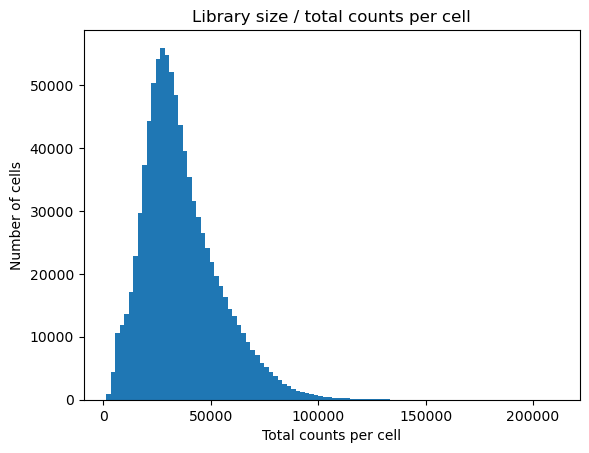

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
adata = sc.read_h5ad("../output/celldive_protein_matrix_celltypes.h5ad")

cell_sums = np.array(adata.X.sum(axis=1)).flatten()
plt.hist(cell_sums, bins=100)
plt.xlabel("Total counts per cell")
plt.ylabel("Number of cells")
plt.title("Library size / total counts per cell")
plt.show()


## 2. Arcsinh transform & scale

Compress imaging dynamic range, keep raw intensities in `layers['raw']`, then z-score markers (clip ±10). Adjust `cofactor` if needed.

This is a continuous-intensity embedding path — we are **not** re-applying binary gates here.


In [ ]:
cofactor = 150.0  # may need to play around with this value
adata.layers["raw"] = adata.X.copy()
adata.X = np.arcsinh(adata.X / cofactor)

sc.pp.scale(adata, max_value=10)


## 3. PCA & neighbors

Build PCA and a kNN graph in PC space. With 23 markers, `n_pcs = min(20, n_vars - 1)`.


In [ ]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=min(20, adata.n_vars - 1))


## 4. UMAP

Slow on the full ~900k-cell object. If this succeeds, avoid re-running it unless neighbors/PCA change.

`sc.tl.umap` only **computes** coordinates (`adata.obsm['X_umap']`); it does not draw a figure. Plotting is in §6–§7.


In [ ]:
sc.tl.umap(adata)


## 5. Leiden clustering

`resolution=0.5` is moderately coarse (fewer, larger clusters). Raise it for finer partitions.

Leiden finds neighborhoods from marker similarity alone — independent of the rule-based `cell_type` labels.


In [ ]:
sc.tl.leiden(adata, resolution=0.5)


## 6. Plot UMAP — postdoc's original

Original plotting code from the postdoc: default Scanpy categorical palette for `cell_type` and Leiden side by side.

**What to look for:**
- Left (`cell_type`): do rule-based labels form clean territories, or mix in the same regions?
- Right (`leiden`): does continuous marker space still show clear structure?
- Especially: do **Unassigned** / **Artifact_Spillover** form one island, or scatter across the manifold?


In [ ]:
sc.pl.umap(adata, color=["cell_type", "leiden"], wspace=0.4)


### Why improve the palette?

With ~19 cell types on a dense cloud, Scanpy's **default categorical colors are hard to tell apart** (many similar blues, greens, and oranges). That makes the left panel misleading for discussion: you cannot reliably track Unassigned vs spillover vs named types.

We keep §6 unchanged so we can show the postdoc the original figure, then the clearer version below, and explain the change as a **visualization** improvement — not a change to the embedding or clustering math.


## 7. Plot UMAP — improved palette

Same embedding and Leiden clusters as §6; only colors / highlighting change:

- Custom high-contrast palette (`adata.uns["cell_type_colors"]`)
- **Unassigned** = black, **Artifact_Spillover** = magenta
- Light transparency so overlaps remain visible
- Extra plot: only those two labels colored; everything else grey


In [ ]:
# Distinct categorical colors. Unassigned / Artifact_Spillover get high-salience colors.
CELL_TYPE_COLORS = {
    "Artifact_Spillover": "#D500F9",  # magenta
    "Unassigned": "#000000",  # black
    "Myofibroblast": "#E69F00",
    "Collagen_stroma": "#56B4E9",
    "Mesenchymal": "#009E73",
    "Epithelial_EPCAM": "#F0E442",
    "Endothelial": "#0072B2",
    "Fibroblast": "#CC79A7",
    "CD8_T": "#D55E00",
    "Epithelial": "#8B8B8B",
    "B_cell": "#1B9E77",
    "CD4_T": "#7570B3",
    "T_cell": "#E7298A",
    "Other_immune": "#66A61E",
    "Macrophage": "#A6761D",
    "Dendritic": "#A6CEE3",
    "Monocyte": "#B2DF8A",
    "M2_like": "#FB9A99",
    "NK_cell": "#CAB2D6",
}

adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
adata.uns["cell_type_colors"] = [
    CELL_TYPE_COLORS.get(str(c), "#7F7F7F") for c in adata.obs["cell_type"].cat.categories
]

sc.pl.umap(
    adata,
    color="cell_type",
    size=8,
    alpha=0.35,
    legend_fontsize=8,
    legend_loc="right margin",
    title="cell_type (high-contrast palette)",
)

sc.pl.umap(
    adata,
    color="leiden",
    palette="tab20",
    size=8,
    alpha=0.35,
    legend_fontsize=8,
    legend_loc="right margin",
    title="leiden",
)

# Easier view of where the investigation targets sit
focus = {"Unassigned", "Artifact_Spillover"}
adata.obs["focus_label"] = (
    adata.obs["cell_type"]
    .astype(str)
    .where(adata.obs["cell_type"].astype(str).isin(focus), other="Other")
    .astype("category")
)
adata.uns["focus_label_colors"] = [
    {"Unassigned": "#000000", "Artifact_Spillover": "#D500F9", "Other": "#D0D0D0"}[str(c)]
    for c in adata.obs["focus_label"].cat.categories
]
sc.pl.umap(
    adata,
    color="focus_label",
    size=8,
    alpha=0.4,
    legend_loc="right margin",
    title="Unassigned / Artifact_Spillover vs other",
)


## 8. Interpretation

Use this section to record what the UMAPs imply for Unassigned / Artifact_Spillover. Update after re-plotting if results change.

### Library size
- Peak around ~25–30k total intensity; bulk roughly ~10–75k; long bright tail.
- Not piled at zero → empty / near-zero **cells** look largely filtered already.
- Remaining per-marker zeros are expected biology (negative markers), not evidence that “zeros weren’t removed.”

### Original vs Leiden structure (from §6)
- **Left (`cell_type`):** many rule-based types mix in the main cloud; only a few groups form sharp islands (e.g. bottom-left stroma-like region; small top-right epithelial-like islands).
- **Right (`leiden`):** ~21 contiguous clusters — continuous marker space **does** have structure that binary rules do not cleanly recover.
- That mismatch is the core finding: gating labels and unsupervised neighborhoods disagree in the dense regions.

### What this means for Unassigned / Artifact_Spillover
| Pattern | Interpretation |
|---|---|
| One tight Leiden island dominated by Unassigned or spillover | Coherent leftover class (missing rule or real artifact type) |
| Spread across many Leiden clusters / mixed into named-type clouds | Residues of gate edges, incomplete rules, or mixed phenotypes — not one junk pile |
| Named types that match Leiden islands cleanly | Rule successes; leave those alone |
| Named types split across several Leiden clusters | Heterogeneity or threshold-unstable assignments within that label |

Observed pattern so far: Unassigned / spillover appear **spread through the manifold** rather than as a single remote blob → favors refining rules/thresholds **per neighborhood**, not assuming one global cutoff fix or a single leftover zero-cell artifact.

### Suggested next quantitative checks
```python
pd.crosstab(adata.obs["leiden"], adata.obs["cell_type"], normalize="index")
```
Then inspect marker means for Leiden clusters enriched in Unassigned or Artifact_Spillover (ties back to `investigate_unassigned_spillover.ipynb`).
